# Emotify — Exploratory Data Analysis & Dataset Cleaning

**Datasets:** Essentia (VGGish + DEAM) and Music2Emo — both produce `valence`, `arousal` (DEAM scale 1–9, midpoint=5) and a mood tag.

**Mood quadrant rules:**

| Mood | Valence | Arousal |
|------|---------|----------|
| Joy | ≥ 5 | ≥ 5 |
| Anger | < 5 | ≥ 5 |
| Pleasure | ≥ 5 | < 5 |
| Sadness | < 5 | < 5 |

**Pipeline:**
1. Understand the raw distributions
2. Remove hard outliers (V/A outside 0–9 or Undefined)
3. Remove ambiguous samples near the decision boundary (V ≈ 5 or A ≈ 5)
4. Save clean datasets and OneHotEncoded versions for model training

> Each dataset gets its own margin — Essentia predictions cluster tightly around the midpoint (low std), so it needs a smaller margin than Music2Emo.

## 1. Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RAW_DIR   = Path('../raw_datasets')
CLEAN_DIR = Path('../clean_datasets')
CLEAN_DIR.mkdir(exist_ok=True)

MOOD_COLORS = {'Joy': '#f4c542', 'Anger': '#e05c4a', 'Pleasure': '#5ab4a0', 'Sadness': '#6a8fc8'}
MOOD_TAGS   = ['Joy', 'Anger', 'Pleasure', 'Sadness']
MIDPOINT    = 5.0

# Margins
# Essentia: smaller margin to keep enough samples
# Music2Emo: larger margin makes sense
MARGIN_ESSENTIA  = 0.1
MARGIN_MUSIC2EMO = 0.2

## 2. Load Raw Datasets

In [14]:
essentia_raw  = pd.read_csv(RAW_DIR / 'essentia_dataset.csv')
music2emo_raw = pd.read_csv(RAW_DIR / 'music2emo_dataset.csv')

print(f'Essentia  : {len(essentia_raw):,} rows')
print(f'Music2Emo : {len(music2emo_raw):,} rows')
print()
print('Essentia head:')
display(essentia_raw.head(3))
print('Music2Emo head:')
display(music2emo_raw.head(3))

Essentia  : 55,701 rows
Music2Emo : 55,701 rows

Essentia head:


,file_path,valence,arousal,mood
0,/Volumes/T7 Shield/Emotify/MTG_Full/00/1002000...,4.826256,4.768503,Sadness
1,/Volumes/T7 Shield/Emotify/MTG_Full/00/1007900...,5.453859,5.741893,Joy
2,/Volumes/T7 Shield/Emotify/MTG_Full/00/1009600...,3.780894,3.842587,Sadness


Music2Emo head:


,file_path,valence,arousal,mood
0,/Volumes/T7 Shield/Emotify/MTG_Full/00/1002000...,5.406875,4.347694,Pleasure
1,/Volumes/T7 Shield/Emotify/MTG_Full/00/1007900...,6.390077,6.267657,Joy
2,/Volumes/T7 Shield/Emotify/MTG_Full/00/1009600...,4.367068,2.710302,Sadness


## 3. Basic Statistics — Raw Datasets

In [15]:
for name, df in [('Essentia', essentia_raw), ('Music2Emo', music2emo_raw)]:
    print(f'=== {name} ===')
    display(df[['valence', 'arousal']].describe().round(3))
    print('Mood distribution:')
    vc = df['mood'].value_counts()
    for mood, count in vc.items():
        print(f'  {mood:<12} {count:>6,}  ({100*count/len(df):.1f}%)')
    print()

=== Essentia ===


,valence,arousal
count,55701.000,55701.000
mean,4.893,4.984
std,0.696,0.778
min,2.832,2.496
25%,4.372,4.388
50%,4.978,5.073
75%,5.422,5.619
max,7.286,7.951


Mood distribution:
  Joy          26,273  (47.2%)
  Sadness      25,229  (45.3%)
  Anger         3,281  (5.9%)
  Pleasure        918  (1.6%)

=== Music2Emo ===


,valence,arousal
count,55701.000,55701.000
mean,5.338,5.025
std,1.116,1.397
min,-1.000,-1.000
25%,4.587,3.980
50%,5.382,5.042
75%,6.130,6.066
max,9.302,9.614


Mood distribution:
  Joy          26,025  (46.7%)
  Sadness      18,271  (32.8%)
  Pleasure      8,926  (16.0%)
  Anger         2,430  (4.4%)
  Undefined        49  (0.1%)



## 4. Raw Distribution Plots

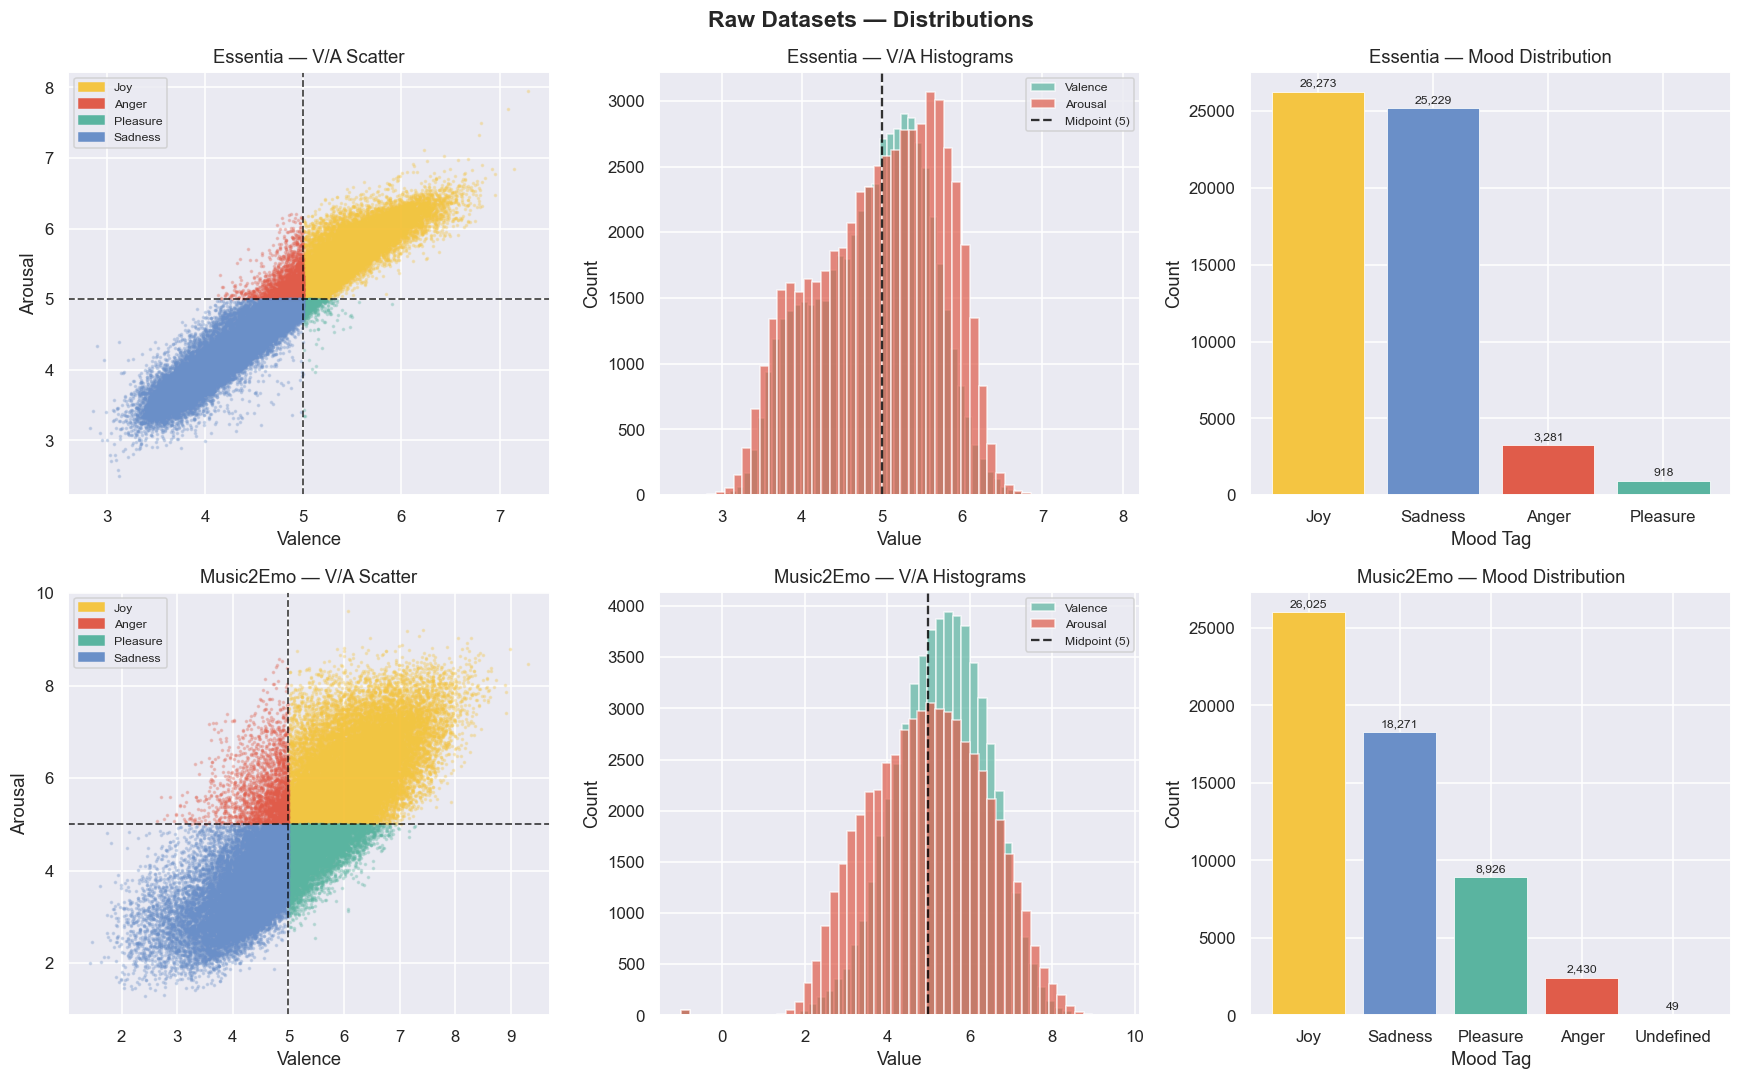

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Raw Datasets — Distributions', fontsize=15, fontweight='bold')

for row_idx, (name, df) in enumerate([('Essentia', essentia_raw), ('Music2Emo', music2emo_raw)]):
    ax_scatter, ax_hist, ax_bar = axes[row_idx]

    # Scatter: Valence vs Arousal
    for mood in MOOD_TAGS:
        sub = df[df['mood'] == mood]
        if len(sub):
            ax_scatter.scatter(sub['valence'], sub['arousal'],
                               c=MOOD_COLORS[mood], label=mood,
                               alpha=0.25, s=2, rasterized=True)
    ax_scatter.axvline(MIDPOINT, color='black', lw=1.2, ls='--', alpha=0.7)
    ax_scatter.axhline(MIDPOINT, color='black', lw=1.2, ls='--', alpha=0.7)
    ax_scatter.set_xlabel('Valence')
    ax_scatter.set_ylabel('Arousal')
    ax_scatter.set_title(f'{name} — V/A Scatter')
    handles = [mpatches.Patch(color=MOOD_COLORS[m], label=m) for m in MOOD_TAGS]
    ax_scatter.legend(handles=handles, markerscale=4, fontsize=8)

    # Histograms
    ax_hist.hist(df['valence'], bins=50, alpha=0.7, label='Valence', color='#5ab4a0')
    ax_hist.hist(df['arousal'], bins=50, alpha=0.7, label='Arousal', color='#e05c4a')
    ax_hist.axvline(MIDPOINT, color='black', lw=1.5, ls='--', alpha=0.8, label='Midpoint (5)')
    ax_hist.set_xlabel('Value')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title(f'{name} — V/A Histograms')
    ax_hist.legend(fontsize=8)

    # Mood bar chart
    vc = df['mood'].value_counts()
    colors = [MOOD_COLORS.get(m, 'grey') for m in vc.index]
    bars = ax_bar.bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vc.values):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                    f'{val:,}', ha='center', va='bottom', fontsize=8)
    ax_bar.set_xlabel('Mood Tag')
    ax_bar.set_ylabel('Count')
    ax_bar.set_title(f'{name} — Mood Distribution')

plt.tight_layout()
plt.show()

## 5. Step 1 — Remove Hard Outliers (V/A < 0 or > 9, Undefined)

Any value outside the DEAM scale [0, 9] is an invalid prediction. Music2Emo returns -1 on failure and marks those rows as `Undefined`.

In [17]:
def remove_hard_outliers(df, name):
    mask = (
        (df['valence'] >= 0) & (df['valence'] <= 9) &
        (df['arousal'] >= 0) & (df['arousal'] <= 9) &
        (df['mood'] != 'Undefined')
    )
    removed = (~mask).sum()
    print(f'{name}: removed {removed} hard-outlier rows → {mask.sum():,} remain')
    return df[mask].copy()

essentia_step1  = remove_hard_outliers(essentia_raw,  'Essentia')
music2emo_step1 = remove_hard_outliers(music2emo_raw, 'Music2Emo')

Essentia: removed 0 hard-outlier rows → 55,701 remain
Music2Emo: removed 57 hard-outlier rows → 55,644 remain


## 6. Step 2 — Margin Analysis (Per-Dataset)

**Idea:** samples where V ≈ 5 *or* A ≈ 5 sit right on a decision boundary — they are ambiguous and can add noise to training. We remove rows where:

```
|valence − 5| < margin  OR  |arousal − 5| < margin
```

Since the two models have very different prediction ranges (Essentia std ≈ 0.7, Music2Emo std ≈ 1.4), **each dataset gets its own margin.** We explore the full range below, then pick the best value for each.

In [18]:
# ── Helper: count retained rows and tag survival for a given margin ──────────
def margin_stats(df, margin):
    if margin == 0:
        kept = df
    else:
        kept = df[
            (abs(df['valence'] - MIDPOINT) >= margin) &
            (abs(df['arousal'] - MIDPOINT) >= margin)
        ]
    vc   = kept['mood'].value_counts()
    pct  = 100 * len(kept) / len(df)
    tags = {m: vc.get(m, 0) for m in MOOD_TAGS}
    return pct, tags

margins = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

print(f'{"Margin":<8} | {"Essentia %":>10} | {"Joy":>6} {"Anger":>6} {"Pleasure":>9} {"Sadness":>8}')
print('-' * 65)
for m in margins:
    pct, tags = margin_stats(essentia_step1, m)
    marker = ' ← chosen' if m == MARGIN_ESSENTIA else ''
    print(f'{m:<8.2f} | {pct:>9.1f}% | {tags["Joy"]:>6,} {tags["Anger"]:>6,} {tags["Pleasure"]:>9,} {tags["Sadness"]:>8,}{marker}')

print()
print(f'{"Margin":<8} | {"Music2Emo %":>10} | {"Joy":>6} {"Anger":>6} {"Pleasure":>9} {"Sadness":>8}')
print('-' * 65)
for m in margins:
    pct, tags = margin_stats(music2emo_step1, m)
    marker = ' ← chosen' if m == MARGIN_MUSIC2EMO else ''
    print(f'{m:<8.2f} | {pct:>9.1f}% | {tags["Joy"]:>6,} {tags["Anger"]:>6,} {tags["Pleasure"]:>9,} {tags["Sadness"]:>8,}{marker}')

Margin   | Essentia % |    Joy  Anger  Pleasure  Sadness
-----------------------------------------------------------------
0.00     |     100.0% | 26,273  3,281       918   25,229
0.05     |      91.5% | 24,859  1,817       256   24,010
0.10     |      85.0% | 23,440    957        73   22,850 ← chosen
0.15     |      79.1% | 21,910    474        28   21,669
0.20     |      74.1% | 20,452    233        15   20,547
0.25     |      69.0% | 18,878     99         6   19,457
0.30     |      64.0% | 17,256     38         4   18,368
0.40     |      54.9% | 14,163     10         1   16,388
0.50     |      46.3% | 11,161      4         0   14,598

Margin   | Music2Emo % |    Joy  Anger  Pleasure  Sadness
-----------------------------------------------------------------
0.00     |     100.0% | 26,017  2,430     8,926   18,271
0.05     |      94.2% | 25,192  2,004     7,754   17,485
0.10     |      88.9% | 24,353  1,664     6,694   16,759
0.15     |      83.8% | 23,542  1,399     5,673   15,996
0.

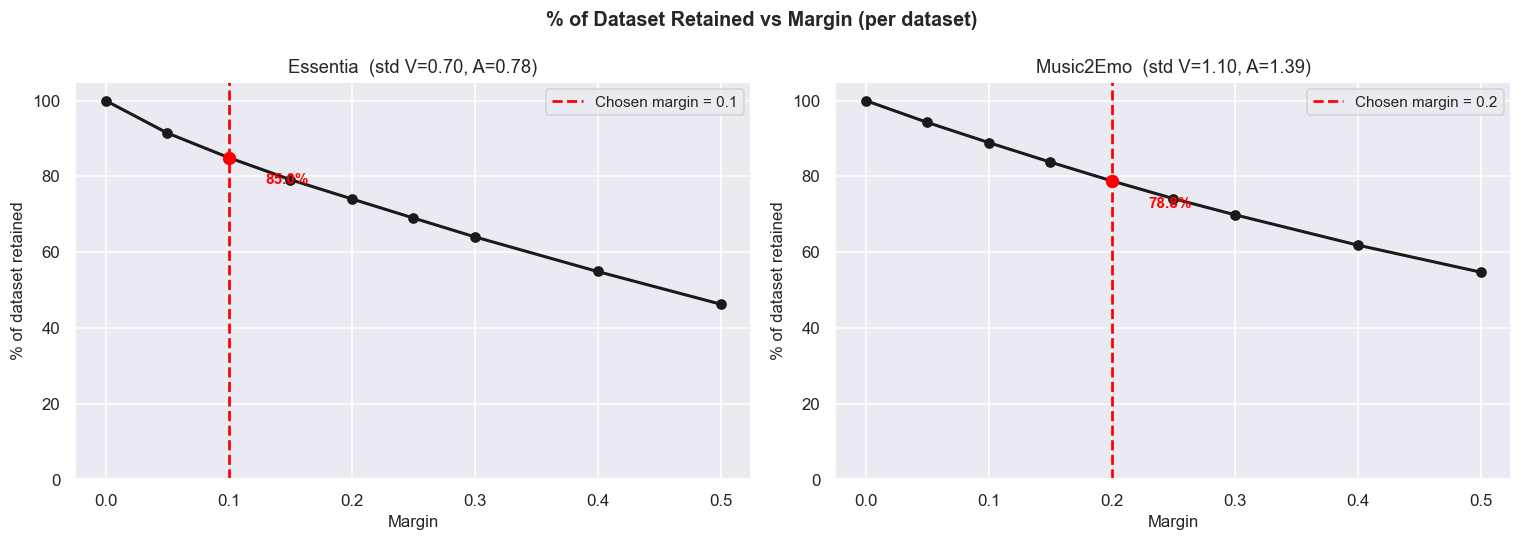

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('% of Dataset Retained vs Margin (per dataset)', fontsize=13, fontweight='bold')

configs = [
    ('Essentia',  essentia_step1,  MARGIN_ESSENTIA),
    ('Music2Emo', music2emo_step1, MARGIN_MUSIC2EMO),
]

for ax, (name, df, chosen_margin) in zip(axes, configs):
    pcts = [margin_stats(df, m)[0] for m in margins]

    ax.plot(margins, pcts, 'ko-', linewidth=2)
    ax.axvline(chosen_margin, color='red', ls='--', lw=1.8, label=f'Chosen margin = {chosen_margin}')
    chosen_pct = margin_stats(df, chosen_margin)[0]
    ax.scatter([chosen_margin], [chosen_pct], color='red', s=60, zorder=5)
    ax.annotate(f'{chosen_pct:.1f}%',
                xy=(chosen_margin, chosen_pct),
                xytext=(chosen_margin + 0.03, chosen_pct - 7),
                fontsize=10, color='red', fontweight='bold')
    ax.set_xlabel('Margin', fontsize=11)
    ax.set_ylabel('% of dataset retained', fontsize=11)
    ax.set_title(f'{name}  (std V={df["valence"].std():.2f}, A={df["arousal"].std():.2f})')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

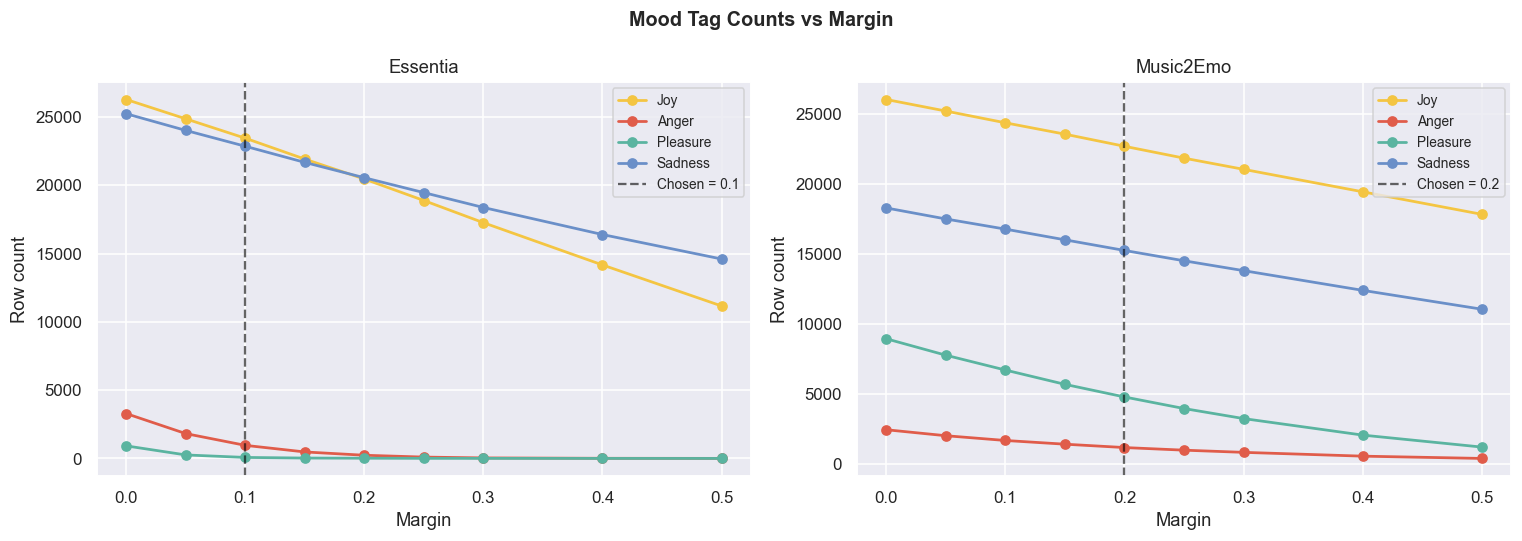

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mood Tag Counts vs Margin', fontsize=13, fontweight='bold')

for ax, (name, df, chosen_margin) in zip(axes, configs):
    for mood in MOOD_TAGS:
        counts = [margin_stats(df, m)[1][mood] for m in margins]
        ax.plot(margins, counts, 'o-', color=MOOD_COLORS[mood], label=mood, linewidth=1.8)
    ax.axvline(chosen_margin, color='black', ls='--', lw=1.5, alpha=0.6, label=f'Chosen = {chosen_margin}')
    ax.set_xlabel('Margin')
    ax.set_ylabel('Row count')
    ax.set_title(name)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

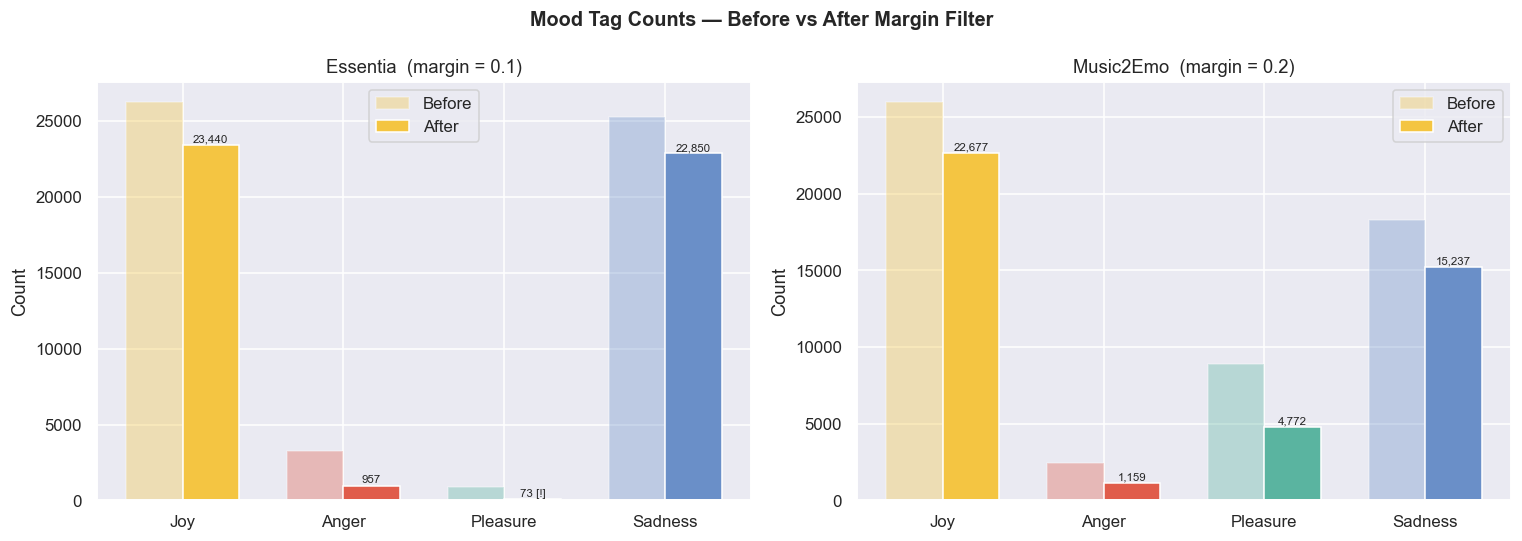

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mood Tag Counts — Before vs After Margin Filter', fontsize=13, fontweight='bold')

for ax, (name, df, chosen_margin) in zip(axes, configs):
    _, tags_after = margin_stats(df, chosen_margin)
    before = [df['mood'].value_counts().get(m, 0) for m in MOOD_TAGS]
    after  = [tags_after[m] for m in MOOD_TAGS]

    x = np.arange(len(MOOD_TAGS))
    w = 0.35
    ax.bar(x - w/2, before, w, label='Before', color=[MOOD_COLORS[m] for m in MOOD_TAGS], alpha=0.35)
    bars2 = ax.bar(x + w/2, after, w, label='After', color=[MOOD_COLORS[m] for m in MOOD_TAGS], alpha=1.0)

    for bar, val in zip(bars2, after):
        flag = ' [!]' if val < 500 else ''
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}{flag}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(MOOD_TAGS)
    ax.set_ylabel('Count')
    ax.set_title(f'{name}  (margin = {chosen_margin})')
    ax.legend()

plt.tight_layout()
plt.show()

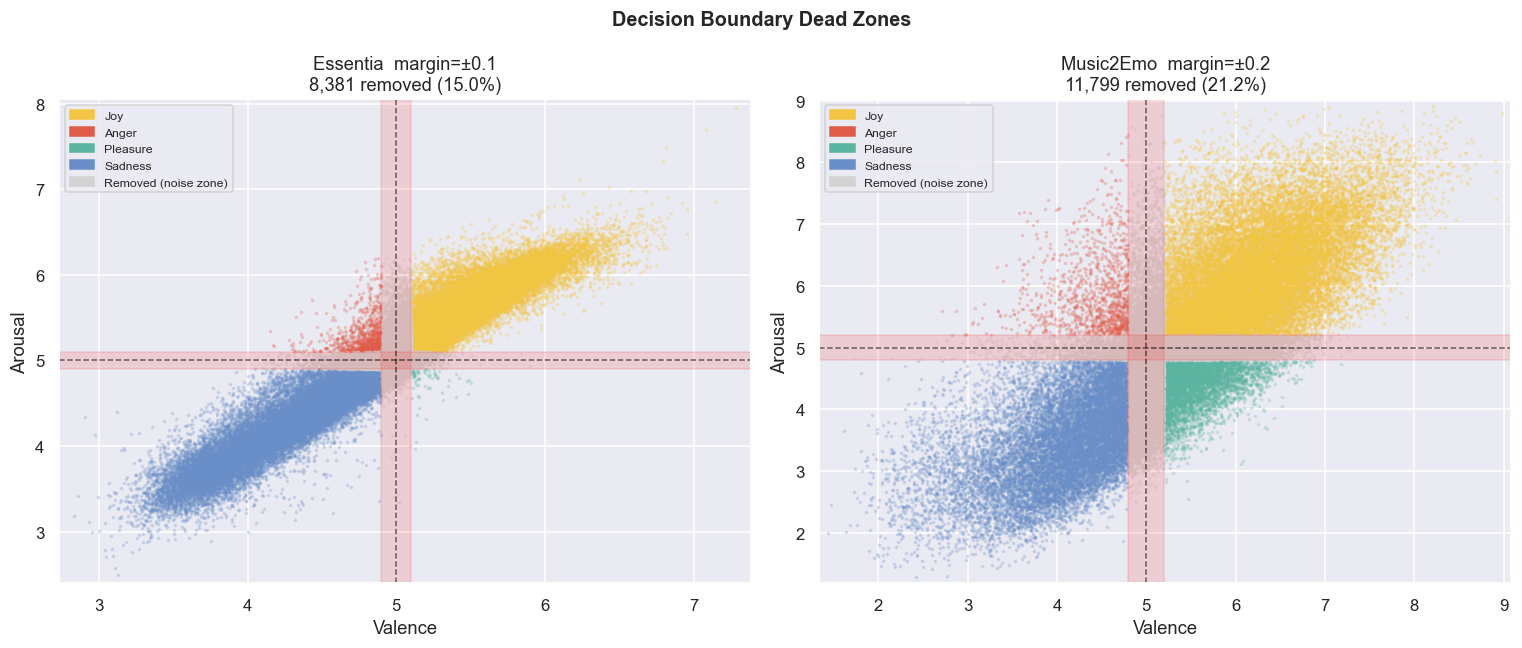

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Decision Boundary Dead Zones', fontsize=13, fontweight='bold')

for ax, (name, df, chosen_margin) in zip(axes, configs):
    in_zone = (
        (abs(df['valence'] - MIDPOINT) < chosen_margin) |
        (abs(df['arousal'] - MIDPOINT) < chosen_margin)
    )
    # kept points coloured by mood
    for mood in MOOD_TAGS:
        sub = df[~in_zone & (df['mood'] == mood)]
        ax.scatter(sub['valence'], sub['arousal'],
                   c=MOOD_COLORS[mood], alpha=0.2, s=2, rasterized=True)
    # removed points in grey
    removed = df[in_zone]
    ax.scatter(removed['valence'], removed['arousal'],
               c='lightgrey', alpha=0.3, s=2, rasterized=True)

    ax.set_xlim(df['valence'].min() - 0.1, df['valence'].max() + 0.1)
    ax.set_ylim(df['arousal'].min() - 0.1, df['arousal'].max() + 0.1)

    # dead zone bands
    ax.axvspan(MIDPOINT - chosen_margin, MIDPOINT + chosen_margin, alpha=0.12, color='red')
    ax.axhspan(MIDPOINT - chosen_margin, MIDPOINT + chosen_margin, alpha=0.12, color='red')
    ax.axvline(MIDPOINT, color='black', lw=1, ls='--', alpha=0.6)
    ax.axhline(MIDPOINT, color='black', lw=1, ls='--', alpha=0.6)

    pct_removed = 100 * in_zone.sum() / len(df)
    ax.set_xlabel('Valence')
    ax.set_ylabel('Arousal')
    ax.set_title(f'{name}  margin=±{chosen_margin}\n{in_zone.sum():,} removed ({pct_removed:.1f}%)')

    mood_handles = [mpatches.Patch(color=MOOD_COLORS[m], label=m) for m in MOOD_TAGS]
    mood_handles.append(mpatches.Patch(color='lightgrey', label='Removed (noise zone)'))
    ax.legend(handles=mood_handles, fontsize=8)

plt.tight_layout()
plt.show()

### ⚠ Essentia Imbalance Note

Essentia predictions cluster tightly around the midpoint (std ≈ 0.7). The **Anger** and **Pleasure** classes are rare even before filtering. Consider using **class weights** or **oversampling** when training on this dataset.

## 7. Step 3 — Apply Margin Filter & Save Clean Datasets

In [23]:
def apply_margin(df, margin):
    mask = (
        (abs(df['valence'] - MIDPOINT) >= margin) &
        (abs(df['arousal'] - MIDPOINT) >= margin)
    )
    return df[mask].copy()

essentia_clean  = apply_margin(essentia_step1,  MARGIN_ESSENTIA)
music2emo_clean = apply_margin(music2emo_step1, MARGIN_MUSIC2EMO)

print('Clean dataset sizes:')
for name, raw, clean in [('Essentia',  essentia_step1,  essentia_clean),
                          ('Music2Emo', music2emo_step1, music2emo_clean)]:
    pct = 100 * len(clean) / len(raw)
    print(f'  {name:<12} {len(raw):>6,} -> {len(clean):>6,} rows  ({pct:.1f}% kept)')

# verify all tags survived
print('\nTag check:')
for name, df in [('Essentia', essentia_clean), ('Music2Emo', music2emo_clean)]:
    vc = df['mood'].value_counts()
    missing = [m for m in MOOD_TAGS if vc.get(m, 0) == 0]
    status = 'OK' if not missing else f'MISSING: {missing}'
    print(f'  {name}: {status}')
    for mood in MOOD_TAGS:
        cnt = vc.get(mood, 0)
        flag = '  [LOW]' if cnt < 500 else ''
        print(f'    {mood:<12} {cnt:>6,}{flag}')

essentia_clean.to_csv(CLEAN_DIR  / 'essentia_clean.csv',  index=False)
music2emo_clean.to_csv(CLEAN_DIR / 'music2emo_clean.csv', index=False)
print('\nSaved to clean_datasets/')

Clean dataset sizes:
  Essentia     55,701 -> 47,320 rows  (85.0% kept)
  Music2Emo    55,644 -> 43,845 rows  (78.8% kept)

Tag check:
  Essentia: OK
    Joy          23,440
    Anger           957
    Pleasure         73  [LOW]
    Sadness      22,850
  Music2Emo: OK
    Joy          22,677
    Anger         1,159
    Pleasure      4,772
    Sadness      15,237

Saved to clean_datasets/


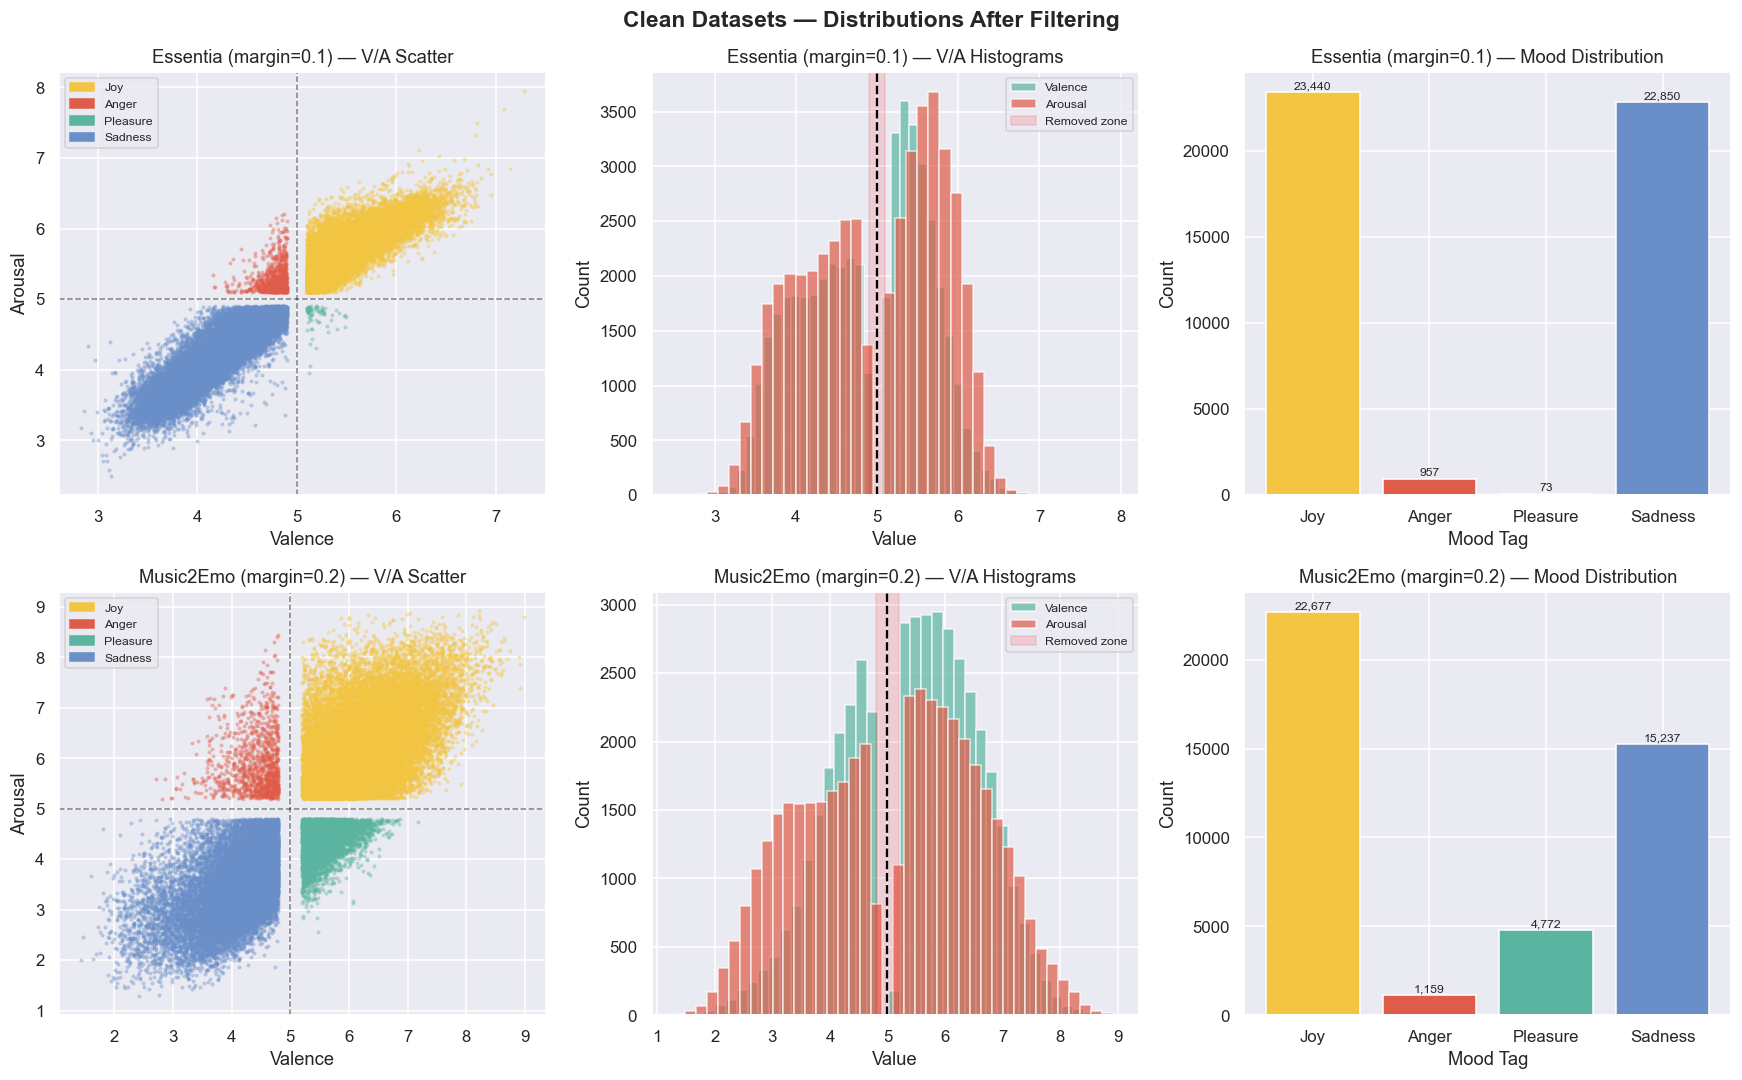

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Clean Datasets — Distributions After Filtering', fontsize=15, fontweight='bold')

plot_configs = [
    (f'Essentia (margin={MARGIN_ESSENTIA})',   essentia_clean,  MARGIN_ESSENTIA),
    (f'Music2Emo (margin={MARGIN_MUSIC2EMO})', music2emo_clean, MARGIN_MUSIC2EMO),
]

for row_idx, (name, df, margin) in enumerate(plot_configs):
    ax_scatter, ax_hist, ax_bar = axes[row_idx]

    for mood in MOOD_TAGS:
        sub = df[df['mood'] == mood]
        if len(sub):
            ax_scatter.scatter(sub['valence'], sub['arousal'],
                               c=MOOD_COLORS[mood], alpha=0.3, s=3, rasterized=True)
    ax_scatter.axvline(MIDPOINT, color='black', lw=1, ls='--', alpha=0.5)
    ax_scatter.axhline(MIDPOINT, color='black', lw=1, ls='--', alpha=0.5)
    ax_scatter.set_xlabel('Valence')
    ax_scatter.set_ylabel('Arousal')
    ax_scatter.set_title(f'{name} — V/A Scatter')
    handles = [mpatches.Patch(color=MOOD_COLORS[m], label=m) for m in MOOD_TAGS]
    ax_scatter.legend(handles=handles, markerscale=4, fontsize=8)

    ax_hist.hist(df['valence'], bins=40, alpha=0.7, label='Valence', color='#5ab4a0')
    ax_hist.hist(df['arousal'], bins=40, alpha=0.7, label='Arousal', color='#e05c4a')
    ax_hist.axvline(MIDPOINT, color='black', lw=1.5, ls='--')
    ax_hist.axvspan(MIDPOINT - margin, MIDPOINT + margin, alpha=0.12, color='red', label='Removed zone')
    ax_hist.set_xlabel('Value')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title(f'{name} — V/A Histograms')
    ax_hist.legend(fontsize=8)

    vc = df['mood'].value_counts().reindex(MOOD_TAGS, fill_value=0)
    bars = ax_bar.bar(vc.index, vc.values,
                      color=[MOOD_COLORS[m] for m in vc.index],
                      edgecolor='white')
    for bar, val in zip(bars, vc.values):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f'{val:,}', ha='center', va='bottom', fontsize=8)
    ax_bar.set_xlabel('Mood Tag')
    ax_bar.set_ylabel('Count')
    ax_bar.set_title(f'{name} — Mood Distribution')

plt.tight_layout()
plt.show()

## 8. Step 4 — OneHotEncoding for Model Training

Each mood becomes a binary column (`mood_Joy`, `mood_Anger`, `mood_Pleasure`, `mood_Sadness`). The string `mood` column is dropped.

In [29]:
def to_ohe(df):
    ohe_cols = ['mood_Joy', 'mood_Anger', 'mood_Pleasure', 'mood_Sadness']
    ohe = pd.get_dummies(df['mood'], prefix='mood').astype(int)
    for col in ohe_cols:
        if col not in ohe.columns:
            ohe[col] = 0

    result = pd.concat([df[['file_path']], ohe[ohe_cols]], axis=1)
    result['file_path'] = result['file_path'].str.replace('MTG_Full', 'MTG_Full_MERT').str.replace('.mp3', '.npy')

    return result

essentia_ohe  = to_ohe(essentia_clean)
music2emo_ohe = to_ohe(music2emo_clean)

print('Essentia OHE sample:')
display(essentia_ohe.head(5))
print('Music2Emo OHE sample:')
display(music2emo_ohe.head(5))

essentia_ohe.to_csv(CLEAN_DIR  / 'essentia_ohe.csv',  index=False)
music2emo_ohe.to_csv(CLEAN_DIR / 'music2emo_ohe.csv', index=False)
print('Saved OHE datasets to clean_datasets/')

Essentia OHE sample:


,file_path,mood_Joy,mood_Anger,mood_Pleasure,mood_Sadness
0,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,0,0,0,1
1,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,1,0,0,0
2,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,0,0,0,1
3,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,1,0,0,0
4,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,1,0,0,0


Music2Emo OHE sample:


,file_path,mood_Joy,mood_Anger,mood_Pleasure,mood_Sadness
0,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,0,0,1,0
1,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,1,0,0,0
2,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,0,0,0,1
3,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,1,0,0,0
4,/Volumes/T7 Shield/Emotify/MTG_Full_MERT/00/10...,1,0,0,0


Saved OHE datasets to clean_datasets/


In [30]:
# Sanity check: OHE column sums must match mood value_counts
print('Label sums (OHE sanity check):')
label_cols = ['mood_Joy', 'mood_Anger', 'mood_Pleasure', 'mood_Sadness']
for name, df in [('Essentia', essentia_ohe), ('Music2Emo', music2emo_ohe)]:
    print(f'\n{name}:')
    for col in label_cols:
        print(f'  {col:<22} {int(df[col].sum()):>6,}')

Label sums (OHE sanity check):

Essentia:
  mood_Joy               23,440
  mood_Anger                957
  mood_Pleasure              73
  mood_Sadness           22,850

Music2Emo:
  mood_Joy               22,677
  mood_Anger              1,159
  mood_Pleasure           4,772
  mood_Sadness           15,237


## 9. Summary

| Dataset | Raw | After hard outliers | After margin | Margin used |
|---------|-----|---------------------|--------------|-------------|
| Essentia | 55,701 | 55,701 | ~47,320 (85%) | 0.1 |
| Music2Emo | 55,701 | 55,644 | ~43,845 (79%) | 0.2 |

**Outputs in `clean_datasets/`:**
| File | Description |
|------|-------------|
| `essentia_clean.csv` | Cleaned Essentia with string mood column |
| `music2emo_clean.csv` | Cleaned Music2Emo with string mood column |
| `essentia_ohe.csv` | OHE version for model training |
| `music2emo_ohe.csv` | OHE version for model training |

**Key findings:**
- Both datasets suffer from **class imbalance** (Joy and Sadness dominate). Consider class weights or oversampling at training time.